# Topic analysis 

This notebook implements the analysis of the topics identified in the comments. 

In [ ]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.cm as cm
import matplotlib.patches as mpatches

import geopandas as gpd

from collections import Counter

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from umap import UMAP

from database.comments import Comments
from database.topics import Topics

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks
from elastic_search_fncs import ElasticSearchFncs
import preprocessing_fncs as prep

nlp_tasks = NLP_Tasks()
esf = ElasticSearchFncs()

cs = Comments(env="dev")
tp = Topics(env='dev')

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


### Read in the .csv with the topic names and representations 

In [2]:
topic_names = pd.read_csv('../model_outputs/topic_model/bertopic_less_topics/object_topics.csv')
topic_names.head()

,Topic,Count,Name,Representation,MaximalMarginalRelevance,KeyBERTInspired,Representative_Docs,doc_1,doc_2,doc_3
0,-1,38355,-1_the_to_and_of,"['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['parking', 'space', 'traffic', 'road', 'impac...",['i object to this proposal on several grounds...,i object to this proposal on several grounds. ...,"firstly, i have been very concerned by the beh...",residents of are already surrounded on two sid...
1,0,14746,0_object_planning_application_following,"['object', 'planning', 'application', 'followi...","['object', 'planning', 'application', 'followi...","['objection', 'following', 'reasons', 'applica...",['i strongly object to this proposal for the f...,i strongly object to this proposal for the fol...,i strongly object to this proposal for the fol...,i strongly object to this proposal for the fol...
2,1,7481,1_trees_garden_green_space,"['trees', 'garden', 'green', 'space', 'of', 't...","['trees', 'garden', 'green', 'space', 'of', 't...","['garden', 'trees', 'greenery', 'tree', 'natur...","['there is no space for a garden.', 'this deve...",there is no space for a garden.,this development is also contrary to the londo...,loss of garden / green space :
3,2,7004,2_parking_traffic_car_already,"['parking', 'traffic', 'car', 'already', 'tran...","['parking', 'traffic', 'car', 'already', 'tran...","['parking', 'car', 'traffic', 'bus', 'parked',...","['2. traffic and parking :', '4. parking', 'pa...",2. traffic and parking :,4. parking,parking :
4,3,6644,3_character_design_out_of,"['character', 'design', 'out', 'of', 'keeping'...","['character', 'design', 'out', 'of', 'keeping'...","['design', 'character', 'appearance', 'style',...","['out of keeping with character of area', 'the...",out of keeping with character of area,the proposal would be out of keeping with the ...,design and character


### Read in the topic dataframe with comments and topic assignments 

In [3]:
tp_df = tp.read_all()
tp_df.head()

,id,comment_id,topic_number,probability,add_date
0,1,230384FUL_16,[],[],2025-10-21
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21
3,4,230384FUL_22,[47],[1.0],2025-10-21
4,5,230384FUL_15,[2],[1.0],2025-10-21


In [4]:
# 'junk' topics - those that don't provide useful information for th purpose of this analysis
bad_topics = {"bad":[-1,0,10,16,31,39,41,42,56,57,88,98]}

# topics that are similar enough to be grouped together
same_topics = {"garden space":[1,43],
               "parking":[2,7,47], 
               "out of character":[3,36,40], 
               "too tall":[5,33],
               "conservation area":[8,35,48],
               "noise pollution":[11,38,46,49],
               "overdevelopment":[13,25],
               "traffic congestion":[18, 21]}

### Simplify the topics 

Simplify the topic assignment as follows:
1. Remove topics whose topic number is >= 50. This reduces the number of topics. 
2. Remove topics in 'bad_topics'. These are the topics which aren't useful for the analysis - i.e. they have clustered based on the word 'objection' or 'thank you' - it doesn't include material information. 
3. Merge similar topics in 'same_topics'. These are topics I have manually identified as being largely undifferentiated. 

In [5]:
# Build a reverse mapping from each old topic to representative topic
topic_map = {}
for _, nums in same_topics.items():
    main = nums[0]
    for n in nums:
        topic_map[n] = main

# Create new columns for updated topics and probabilities with empty lists
tp_df['topic_number_updated'] = [[] for _ in range(len(tp_df))]
tp_df['probability_updated'] = [[] for _ in range(len(tp_df))]

# Process each row to filter and merge topics
for i in range(len(tp_df)):
    topics = tp_df.at[i, 'topic_number']
    probs = tp_df.at[i, 'probability']

    # filter out topics >= 50
    filtered = [(t, p) for t, p in zip(topics, probs) if t < 50]

    # filter out topics in bad_topics
    filtered = [(t, p) for t, p in filtered if all(t not in v for v in bad_topics.values())]

    # merge topics in same_topics
    merged = {}
    for t, p in filtered:
        new_t = topic_map.get(t, t)  # replace with main topic if part of a group
        merged[new_t] = merged.get(new_t, 0) + p  # sum probabilities

    # store results
    tp_df.at[i, 'topic_number_updated'] = list(merged.keys())
    tp_df.at[i, 'probability_updated'] = list(merged.values())


In [6]:
tp_df.head()

,id,comment_id,topic_number,probability,add_date,topic_number_updated,probability_updated
0,1,230384FUL_16,[],[],2025-10-21,[],[]
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21,[2],[0.532771282582039]
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21,"[19, 13]","[0.7651527090417625, 0.1552818674969217]"
3,4,230384FUL_22,[47],[1.0],2025-10-21,[2],[1.0]
4,5,230384FUL_15,[2],[1.0],2025-10-21,[2],[1.0]


### Create a mapping between the topic number and topic names 

In [7]:
# create dictionary mapping topic number to name
topic_dict = dict(zip(topic_names['Topic'], topic_names['Name']))

# reduce to only include topics present in the updated topic/comment dataframe
unique_topics = set()
for topics in tp_df['topic_number_updated']:
    unique_topics.update(topics)

filtered_topic_dict = {k: v for k, v in topic_dict.items() if k in unique_topics}

# remove number and underscores from topic names
for k in filtered_topic_dict:
    name = filtered_topic_dict[k]
    name = name.split('_', 1)[1] if '_' in name else name
    name = name.replace('_', ' ')
    filtered_topic_dict[k] = name

In [8]:
# Flatten topics and count frequencies in the topic/common dataframe
all_topics = [t for topics in tp_df['topic_number_updated'] for t in topics]
topic_counts = Counter(all_topics)

# Sort by frequency (descending)
topic_counts = dict(sorted(topic_counts.items(), key=lambda x: x[1], reverse=True))

### Create hex colour mapping for the topics 

In [9]:
custom_hex_colors = [
    "#1871b0", "#82d64b", "#fe9e29", "#cf4242", "#a373d0",
    "#865349", "#F2F527", "#494A2A", "#df51b4", "#7d6565", 
    "#1cc6d9", "#453D70", "#bcbd22", "#09A31B", "#91e0b0",
    "#a1c7e3", "#d1e7c3", "#e3d1bc", "#b48989", "#4e0f88",
    "#D12E0E", "#B4B489", "#EDEEE0", "#df9fcc", "#e58888", 
    "#a8dadf", "#7A6CC8", "#A7A70A", "#A1D6A7", "#27c968"
]

# map custom_hex_colors to topics in filtered_topic_dict
color_map = {topic: custom_hex_colors[i % len(custom_hex_colors)]
             for i, topic in enumerate(filtered_topic_dict.values())}

### Simplify the topic names

Dictionary mapping the topic representations generated by BERTopic to simplified names for the sake of analysis/plotting. 

In [10]:
x_label_map = {'parking traffic car already':'loss of parking',
 'trees garden green space':'loss of gardens',
 'character design out of':'out of character',
 'height scale buildings tall':'too tall',
 'noise disruption pollution will':'noise pollution',
 'light sunlight daylight loss':'loss of light',
 'density overdevelopment overcrowding dense':'overdevelopment',
 'amenity impact on of':'impact on amenities',
 'conservation heritage listed area':'heritage area',
 'family bedroom housing social':'wrong housing type',
 'privacy overlooking loss windows':'loss of privacy',
 'congested parking already traffic':'traffic congestion',
 'safety dangerous traffic fire':'unsafe',
 'bin refuse storage bins':'lack of bins',
 'height light privacy of':'too tall, loss of light',
 'environment wildlife biodiversity local': 'loss of wildlife',
 'water drainage flooding flood': 'flood risk',
 'view from the my': 'loss of view',
 'consultation engagement process been': 'insufficent community enagement',
 'impact parking on amenity': 'parking and amenity impact',
 'dust pollution air noise': 'air pollution',
 'business shop retail shops': 'impact on retail',
 'affordable housing homes rent': 'not affordable',
 'ugly eyesore visual an': 'eyesore',
 'disabled parking elderly accessible': 'lack of disabled parking',
 'parking character is traffic': 'parking and traffic',
 'carbon climate sustainable energy': 'not environmentally sustainable',
 'park green space trees': 'loss of parks',
 'value of community the': 'bad for community',
 'rent dwelling bed viability': 'rental properties'
}

### Plot barchart of top topics with frequency 

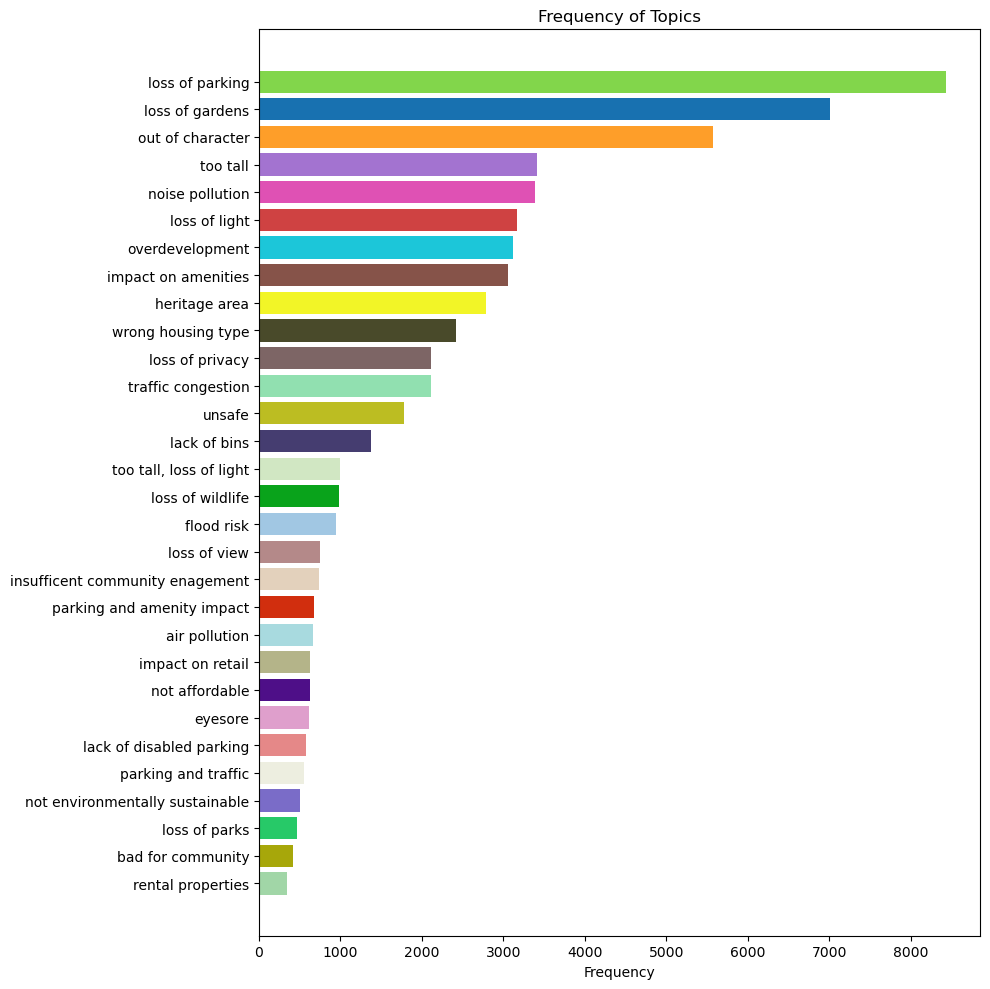

In [11]:
# Convert to parallel lists for plotting (categorical x-axis)
x_labels = [filtered_topic_dict[k] for k in topic_counts.keys()]
y_values = list(topic_counts.values())

bar_colors = [color_map[topic] for topic in x_labels]

new_x_labels = [x_label_map.get(label, label) for label in x_labels]

plt.figure(figsize=(10, 10))
plt.barh(new_x_labels, y_values, color=bar_colors)

plt.gca().invert_yaxis()
plt.xlabel('Frequency')
plt.title('Frequency of Topics')

plt.tight_layout()
plt.savefig('../results/figures/object_topics_frequency.png', dpi=500)

plt.show()

In [12]:
# print frequency table of topics
freq_table = pd.DataFrame({
    'Topic': new_x_labels,
    'Frequency': y_values
})
# add a column with percentage
freq_table['Percentage'] = (freq_table['Frequency'] / freq_table['Frequency'].sum()) * 100
freq_table


,Topic,Frequency,Percentage
0,loss of parking,8427,14.001595
1,loss of gardens,7007,11.642242
2,out of character,5576,9.264613
3,too tall,3418,5.679062
4,noise pollution,3386,5.625893
5,loss of light,3161,5.252052
6,overdevelopment,3115,5.175622
7,impact on amenities,3051,5.069285
8,heritage area,2785,4.627322
9,wrong housing type,2412,4.007577


## Match and merge topics to comments 

Analyse the topics at the individual comment level. 

In [13]:
cs_df = cs.read_all()

df = pd.merge(cs_df, tp_df[['comment_id', 'topic_number_updated', 'probability_updated']], on='comment_id', how='left')

In [14]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,topic_number_updated,probability_updated
0,94578,Barnet,21/3726/FUL_36,21/3726/FUL,13 baxendale london n20 oeg,Objects,2021-11-26,OBJECTIONS\n\n1. My comments submitted already...,2025-04-11,NaN,NaN,OBJECTIONS\n\n1. My comments submitted already...,None,-0.107717,"[29, 24, 6]","[1.0, 1.0, 0.42374573153691175]"
1,89760,Barnet,23/4531/FUL_7,23/4531/FUL,140 high road East Finchley London N2 9ED,Objects,2023-11-19,"We currently own the building next door, 140, ...",2025-04-10,51.590681,-0.164280,"We currently own the building next door, 140, ...",E09000003,-0.141803,"[5, 1, 4, 6, 14]","[0.3453696783017621, 0.050383790484089766, 0.3..."
2,75195,Barnet,23/3688/FUL_1,23/3688/FUL,63 Lodge Lane London N12 8JG,Objects,2023-10-06,"Dear Sir/ Madam,\nApologies for missing the on...",2025-04-07,51.616629,-0.177801,"Dear Sir/ Madam,\nApologies for missing the on...",E09000003,-0.219902,"[6, 4]","[0.43887427738451523, 0.5987158352935015]"
3,80797,Ealing,214950FUL_104,214950FUL,Oakwood ct London W148jf W148jf,Objects,2021-09-15,I have grandchildren attending Ark Byron\nPlea...,2025-04-09,51.499900,-0.207550,I have grandchildren attending \nPlease do not...,E09000020,-0.447377,[44],[0.12318053505783118]
4,92152,Ealing,215983FUL_416,215983FUL,51 Manton Avenue Hanwell W7 2DY W7 2DY,Objects,2021-11-11,I am distressed to see a building proposal app...,2025-04-10,51.504120,-0.329371,I am distressed to see a building proposal app...,E09000009,-0.326843,[],[]


In [15]:
# make sure 'topic_number_updated' and 'probability_updated' are lists
df['topic_number_updated'] = df['topic_number_updated'].apply(lambda x: x if isinstance(x, list) else [])
df['probability_updated'] = df['probability_updated'].apply(lambda x: x if isinstance(x, list) else [])

# make sure 'topic_number_updated' are integers
df['topic_number_updated'] = df['topic_number_updated'].apply(lambda lst: [int(i) for i in lst])

# run preprocessing format_df function
df = prep.format_df(df, borough_col_name='council')

### Plot barchart of topic frequency by council 

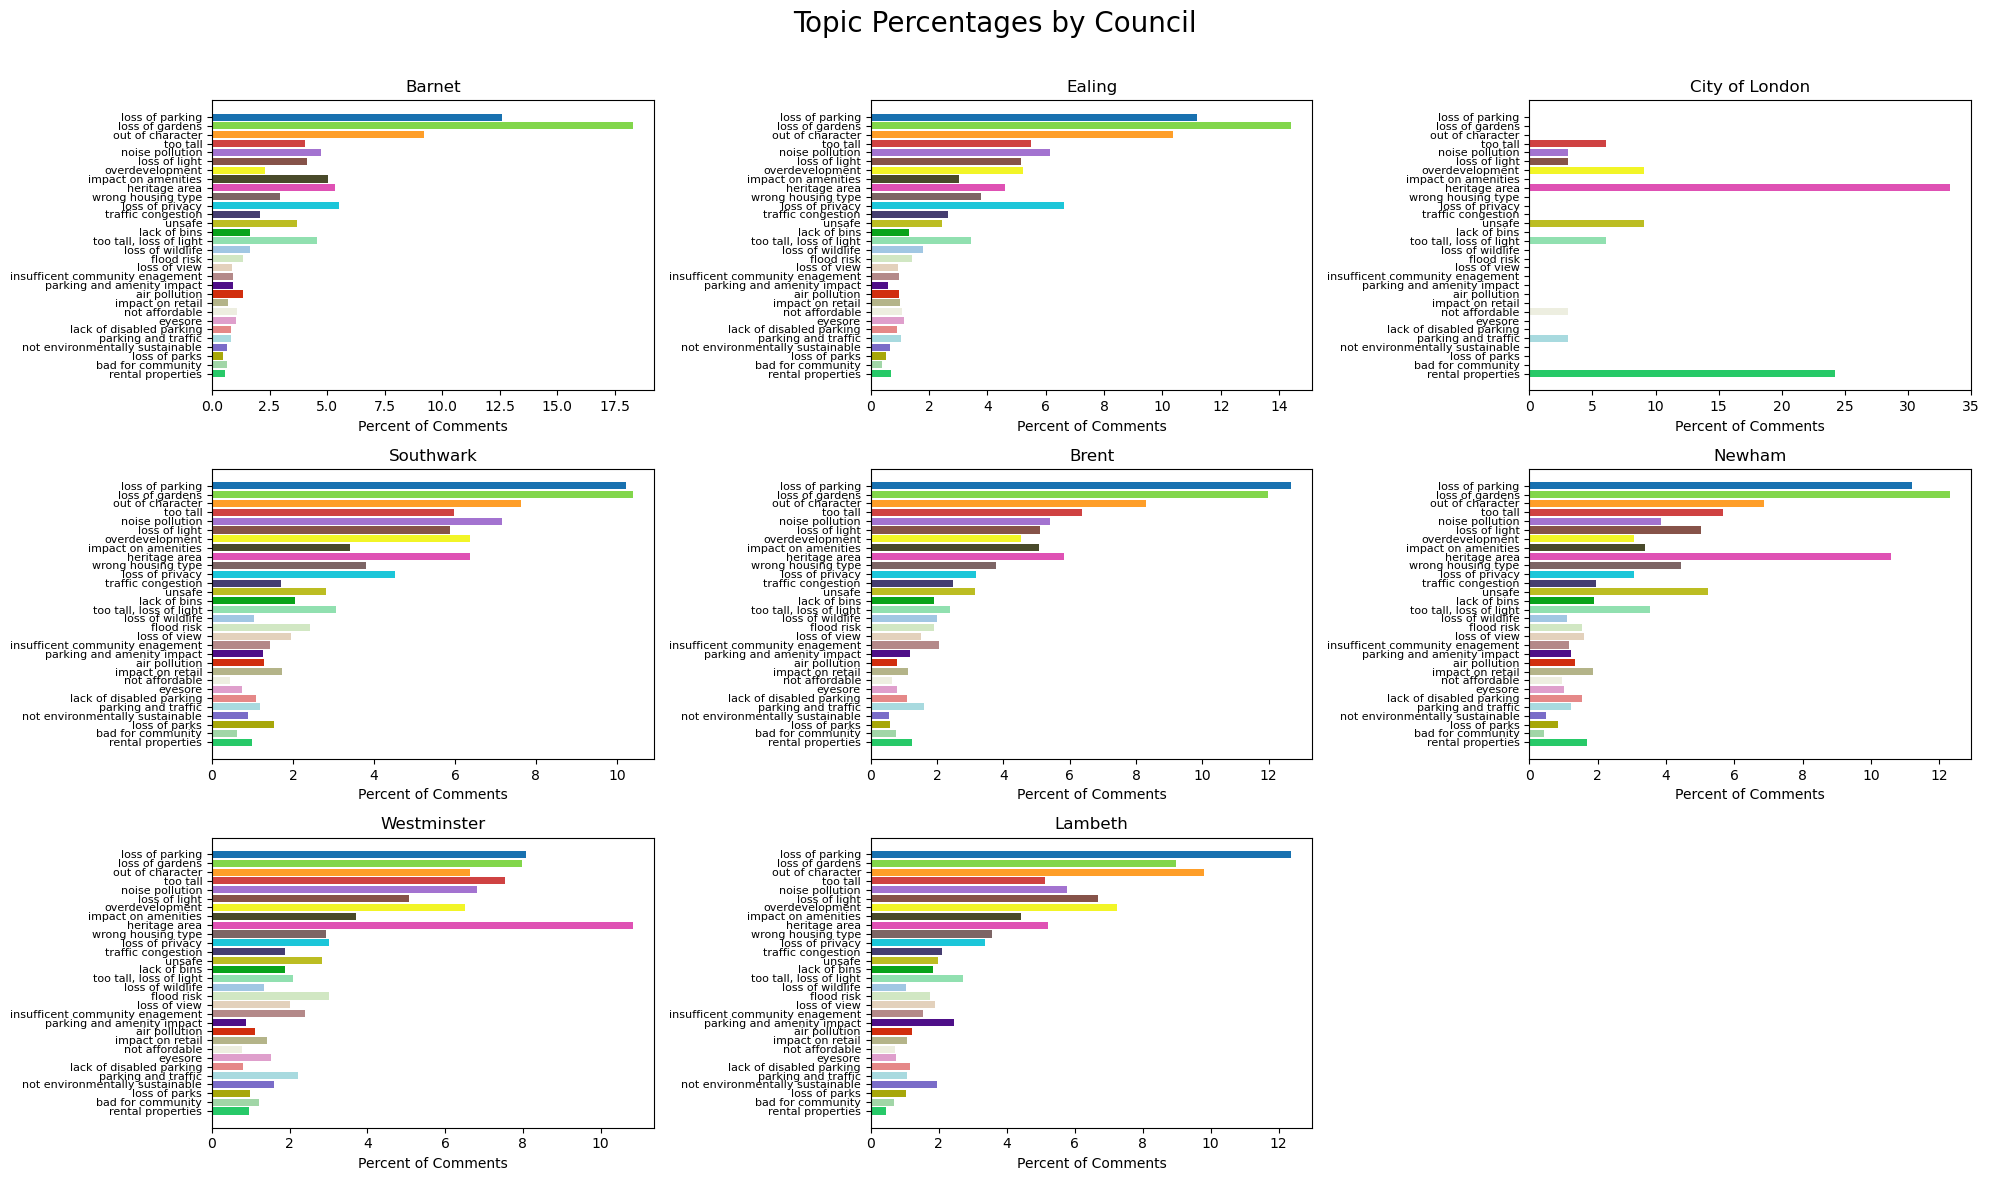

In [ ]:
councils = df['council'].unique()

# Ordered topic IDs (numeric keys)
ordered_topic_ids = list(filtered_topic_dict.keys())

# Color map keyed by topic ID
color_map = {
    topic_id: custom_hex_colors[i % len(custom_hex_colors)]
    for i, topic_id in enumerate(ordered_topic_ids)
}

# Create subplot grid
num_councils = len(councils)
cols = 3
rows = math.ceil(num_councils / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for ax, council in zip(axes, councils):
    council_df = df[df['council'] == council]

    # Flatten topics into a list of numeric IDs
    all_topics = [t for topics in council_df['topic_number_updated'] for t in topics]

    # Count frequencies
    topic_counts = Counter(all_topics)
    total_comments = sum(topic_counts.values())

    # Percent of total
    y_values = [
        (topic_counts.get(topic_id, 0) / total_comments) * 100 if total_comments > 0 else 0
        for topic_id in ordered_topic_ids
    ]

    x_labels = [filtered_topic_dict[tid] for tid in ordered_topic_ids]
    bar_colors = [color_map[tid] for tid in ordered_topic_ids]

    ax.barh(new_x_labels, y_values, color=bar_colors)
    ax.set_title(council)
    ax.invert_yaxis()
    ax.set_xlabel('Percent of Comments')
    ax.tick_params(axis='y', labelsize=8)

# Hide any empty subplot panels
for i in range(len(councils), len(axes)):
    fig.delaxes(axes[i])

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### Plot sentiment scores by council 

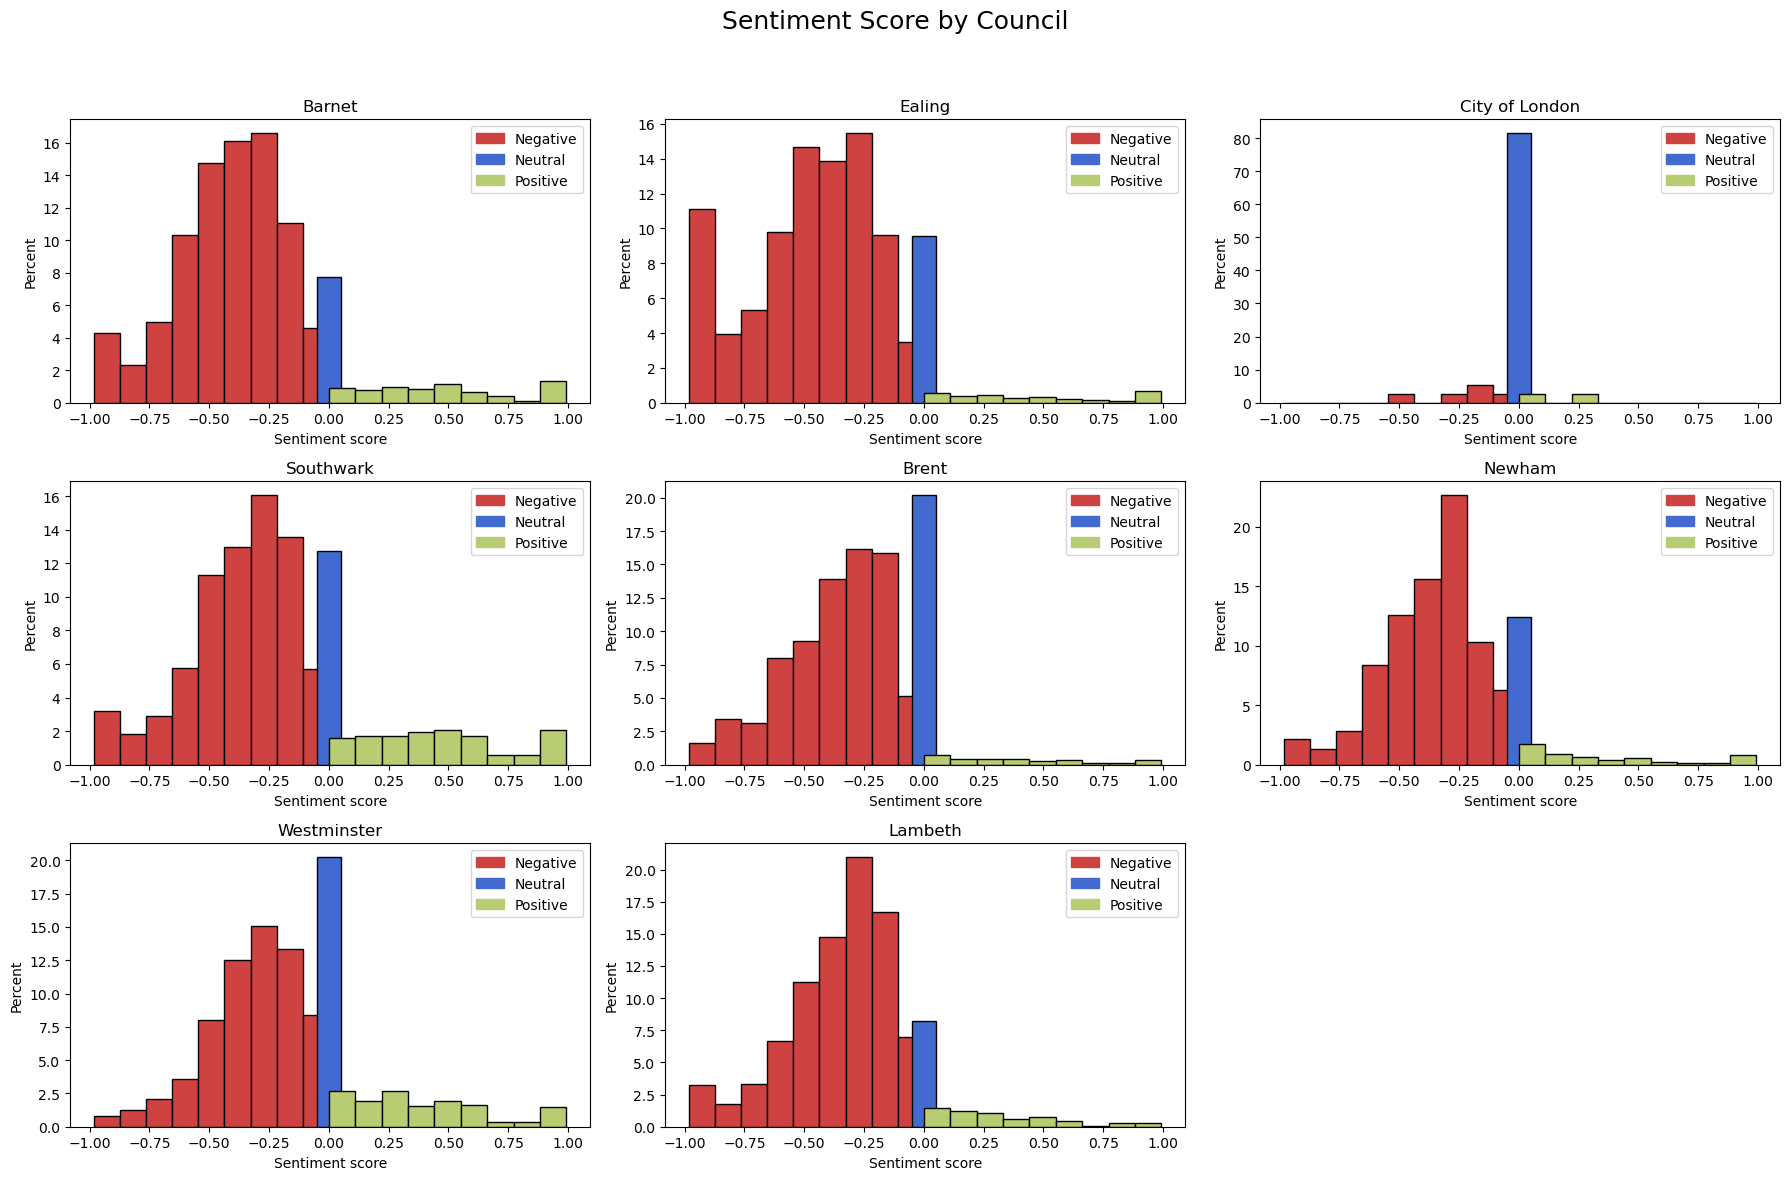

In [21]:
cols = 3
rows = math.ceil(len(councils) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = axes.flatten()

neg_bins = np.linspace(df['sentiment_score'].min(), -0.0001, 10)
pos_bins = np.linspace(0.0001, df['sentiment_score'].max(), 10)

for ax, council in zip(axes, councils):
    council_df = df[df['council'] == council]
    scores = council_df['sentiment_score'].dropna()
    total = len(scores)

    zeros = (scores == 0).sum()
    neg_scores = scores[scores < 0]
    pos_scores = scores[scores > 0]

    # Histogram for negative and positive values
    neg_counts, neg_edges = np.histogram(neg_scores, bins=neg_bins)
    pos_counts, pos_edges = np.histogram(pos_scores, bins=pos_bins)

    neg_perc = neg_counts / total * 100
    pos_perc = pos_counts / total * 100
    zero_perc = zeros / total * 100

    # Plot negative bins (red)
    ax.bar(neg_edges[:-1], neg_perc, width=np.diff(neg_edges), color="#cf4242", edgecolor='black', align='edge')

    # Plot zero bin (blue)
    if zero_perc > 0:
        ax.bar(0, zero_perc, width=0.1, color="#426acf", edgecolor='black', align='center')

    # Plot positive bins (green)
    ax.bar(pos_edges[:-1], pos_perc, width=np.diff(pos_edges), color="#b8cd73", edgecolor='black', align='edge')

    ax.set_title(council)
    ax.set_xlabel('Sentiment score')
    ax.set_ylabel('Percent')

    # Add a nice legend using Patch handles
    handles = [
        mpatches.Patch(color="#cf4242", label='Negative'),
        mpatches.Patch(color="#426acf", label='Neutral'),
        mpatches.Patch(color="#b8cd73", label='Positive')
    ]
    ax.legend(handles=handles, loc='upper right')

# Hide unused axes
for i in range(len(councils), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle('Sentiment Score by Council', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../results/figures/sentiment_by_council.png', dpi=500)
plt.show()


## Plot the topic embedding for the documents 

In [26]:
sentence_model = SentenceTransformer("Bea-Taylor/objection_fine_tuned_4")
topic_model = BERTopic.load("../model_outputs/topic_model/bertopic_less_topics/full_model/object_model", embedding_model=sentence_model)

In [27]:
# Load the comments from the database
df = cs.read_all()

df_objects = df[df['stance']=='Objects']

### Preprocess the text data

# split text on newlines, this function preserves the metadata by exploding the dataframe
df_objects_split = nlp_tasks.split_text_on_newline(df=df_objects, column='cleaned_comment_text')

print(f'\n Length after splitting data')
print('Objects:', len(df_objects_split))

# split the text by chunks of a maximum length, this function preserves the metadata by exploding the dataframe

max_length_tokens = sentence_model.get_max_seq_length()

df_objects_split = nlp_tasks.split_text_by_length(df=df_objects_split, column='cleaned_comment_text', max_length=max_length_tokens, overlap=40, filter_empty=False, filter_short=False)

print(f'\n Length after chunking data')
print('Objects:', len(df_objects_split))

cleaned_object_text = df_objects_split['cleaned_comment_text'].tolist()

Token indices sequence length is longer than the specified maximum sequence length for this model (266 > 256). Running this sequence through the model will result in indexing errors



 Length after splitting data
Objects: 140946

 Length after chunking data
Objects: 141965


In [28]:
embeddings = sentence_model.encode(cleaned_object_text, show_progress_bar=True)
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

Batches: 100%|██████████| 4437/4437 [07:08<00:00, 10.36it/s]


In [29]:
topics = topic_model.get_document_info(cleaned_object_text)['Topic'].to_numpy()

Number of unique topics to plot: 30


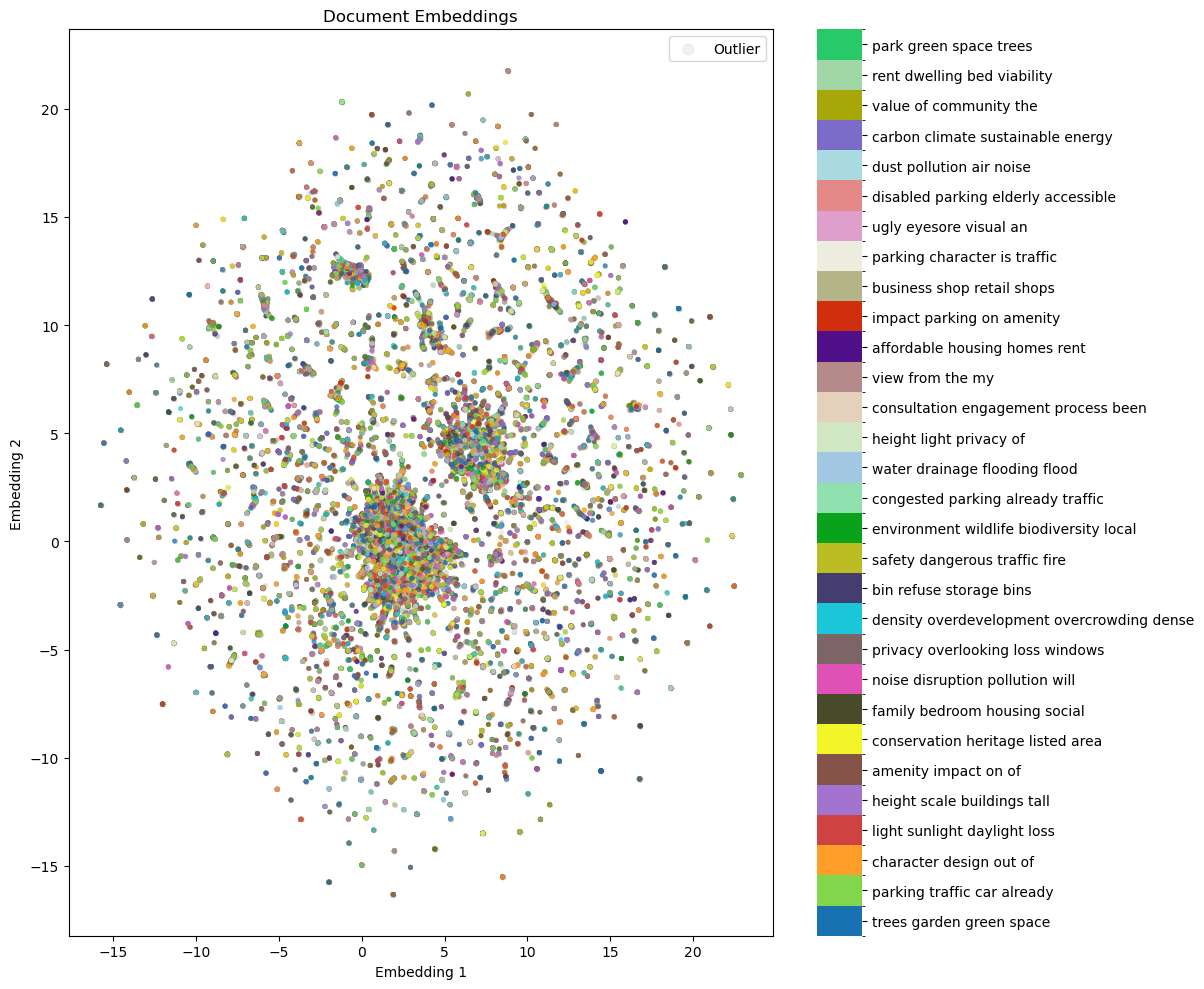

In [30]:
# --- build reduced topic list ---
unique_topics = set()
for topic_list in tp_df['topic_number_updated']:
    unique_topics.update(topic_list)
unique_topics = sorted(unique_topics)

n_topics = len(unique_topics)

print(f'Number of unique topics to plot: {n_topics}')

# --- color palette ---
colors_for_topics = [custom_hex_colors[i % len(custom_hex_colors)] for i in range(n_topics)]
cmap = ListedColormap(colors_for_topics)
norm = BoundaryNorm(boundaries=np.arange(-0.5, n_topics + 0.5, 1), ncolors=n_topics)

# --- figure and axis ---
fig, ax = plt.subplots(figsize=(12, 10))

# ensure boolean masks are proper boolean NumPy arrays
is_outlier = (topics == -1)
is_reduced_topic = np.array([t in unique_topics for t in topics], dtype=bool)

# --- Plot outliers (gray) ---
ax.scatter(
    reduced_embeddings[is_outlier, 0],
    reduced_embeddings[is_outlier, 1],
    color='lightgrey',
    s=7,
    alpha=0.3,
    label='Outlier'
)

# --- Plot other topics (not in reduced list) in gray ---
ax.scatter(
    reduced_embeddings[~is_outlier & ~is_reduced_topic, 0],
    reduced_embeddings[~is_outlier & ~is_reduced_topic, 1],
    color='lightgray',
    s=7,
    alpha=0.3
)

# --- Plot points in your reduced topic list (colored) ---
ax.scatter(
    reduced_embeddings[~is_outlier & is_reduced_topic, 0],
    reduced_embeddings[~is_outlier & is_reduced_topic, 1],
    c=[unique_topics.index(t) for t in topics[~is_outlier & is_reduced_topic]],
    cmap=cmap,
    norm=norm,
    s=7,
    alpha=0.6
)



# --- Labels and layout ---
ax.set_title('Document Embeddings')
ax.set_xlabel('Embedding 1')
ax.set_ylabel('Embedding 2')

# --- Discrete colorbar for selected topics only ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(n_topics))
cbar.ax.set_yticklabels([filtered_topic_dict.get(t, f'Topic {t}') for t in unique_topics])
cbar.outline.set_visible(False)

ax.legend(markerscale=3)
plt.tight_layout()

plt.savefig('../results/figures/object_topics_scatter.png', dpi=500)
plt.show()